# Generate Maps, Figures, and Visuals

Outputs are saved to `../plots/`.



In [67]:
from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BASE = Path('..')
OUT = BASE / 'plots'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 160,
    'savefig.dpi': 220,
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})



## Load Data



In [68]:
cafes = pd.read_csv(BASE / 'data/synthetic/cafes.csv')
summary = pd.read_csv(BASE / 'data/synthetic/cafe_summary.csv')
demands = pd.read_csv(BASE / 'data/synthetic/demands.csv')
products = pd.read_csv(BASE / 'data/synthetic/products.csv')
vans = pd.read_csv(BASE / 'data/synthetic/vans.csv')
locations = pd.read_csv(BASE / 'data/real/locations.csv')
distance_matrix = pd.read_csv(BASE / 'data/real/distance_matrix.csv', index_col=0)
time_matrix = pd.read_csv(BASE / 'data/real/time_matrix.csv', index_col=0)

cafe_data = cafes.merge(
    summary[['cafe_id', 'total_daily_weight_kg', 'total_daily_revenue']],
    on='cafe_id',
    how='left',
)
depot = locations[locations['is_depot'].eq('yes')].iloc[0]

print('cafes:', cafes.shape)
print('locations:', locations.shape)
print('distance matrix:', distance_matrix.shape)
print('time matrix:', time_matrix.shape)



cafes: (34, 5)
locations: (35, 4)
distance matrix: (35, 35)
time matrix: (35, 35)


## 1. Cafe Network Demand Bubble Map



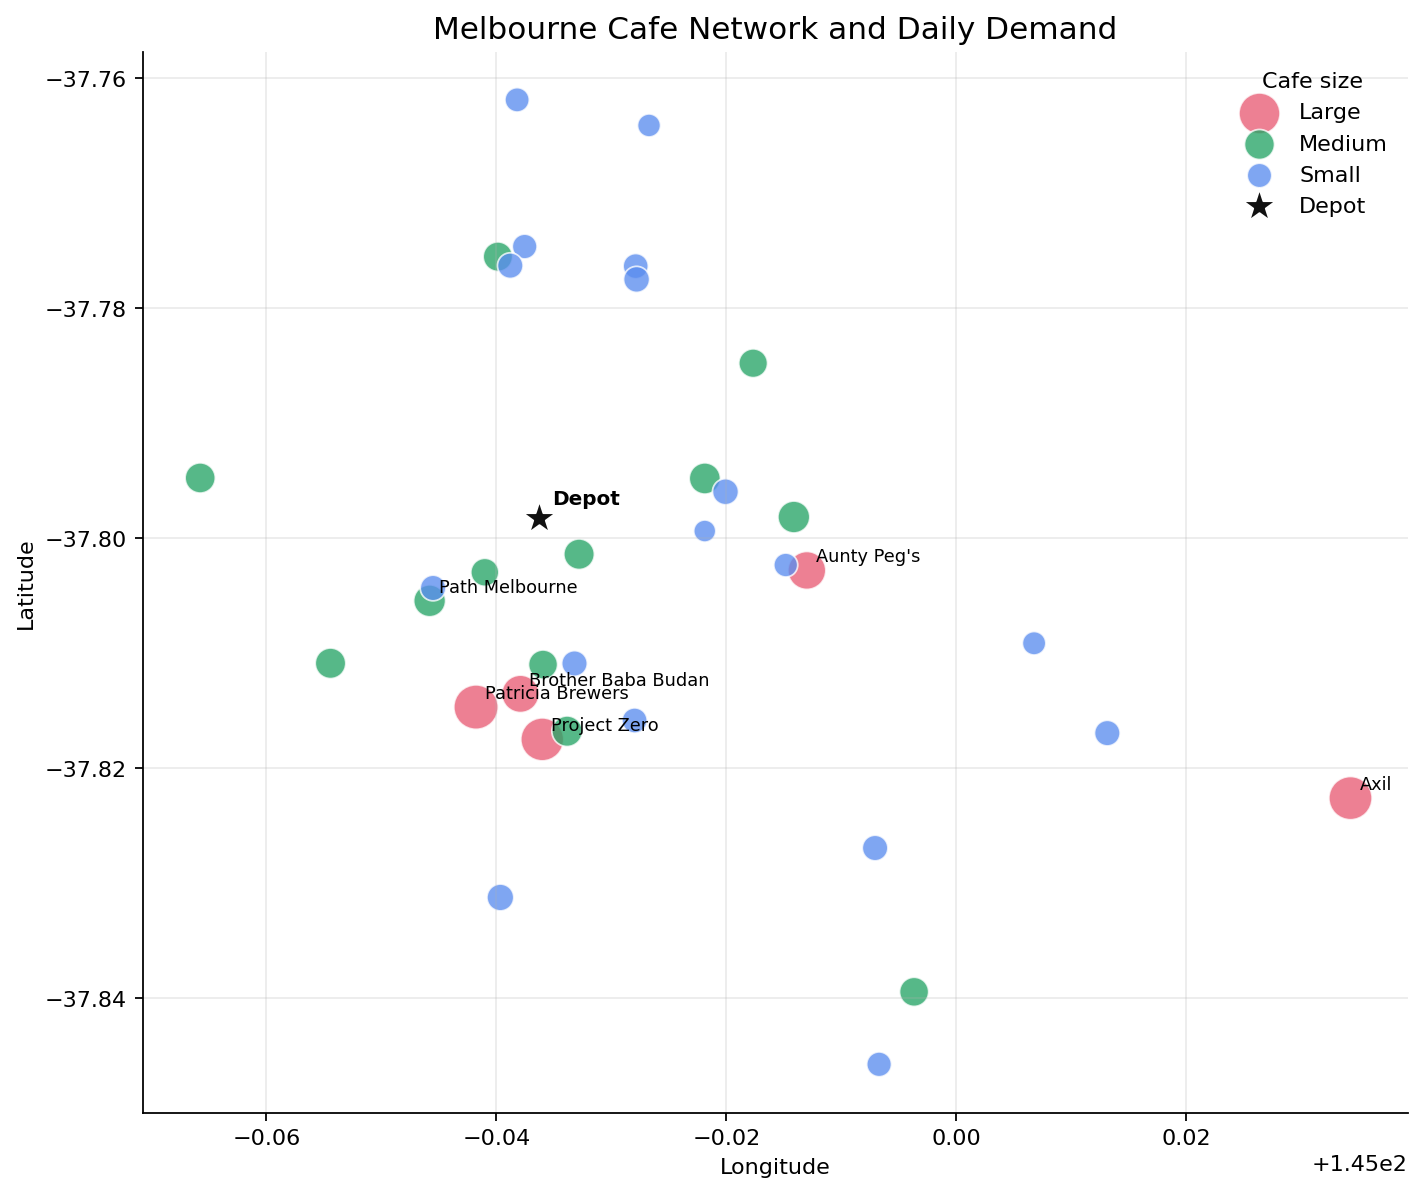

In [69]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = {'small': '#5B8DEF', 'medium': '#27A567', 'large': '#E85D75'}

for size, group in cafe_data.groupby('size'):
    ax.scatter(
        group['longitude'],
        group['latitude'],
        s=group['total_daily_weight_kg'] * 4.2 + 30,
        c=colors.get(size, '#777777'),
        alpha=0.78,
        edgecolor='white',
        linewidth=0.8,
        label=size.title(),
    )

ax.scatter(
    depot['longitude'],
    depot['latitude'],
    s=260,
    marker='*',
    c='#111111',
    edgecolor='white',
    linewidth=1.0,
    label='Depot',
)

for _, row in cafe_data.nlargest(6, 'total_daily_weight_kg').iterrows():
    label = row['cafe_name'].replace(' Coffee', '').replace(' Roasters', '')
    ax.annotate(label, (row['longitude'], row['latitude']), xytext=(4, 4), textcoords='offset points', fontsize=8)

ax.annotate('Depot', (depot['longitude'], depot['latitude']), xytext=(6, 6), textcoords='offset points', fontsize=9, weight='bold')
ax.set_title('Melbourne Cafe Network and Daily Demand')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(frameon=False, loc='best', title='Cafe size')
ax.set_aspect('equal', adjustable='box')
fig.tight_layout()
fig.savefig(OUT / '01_cafe_network_demand_bubble.png', bbox_inches='tight')
plt.show()



This map shows the WCC depot and Melbourne cafe/customer locations. Larger markers indicate cafes with higher total daily delivery demand, so it explains the geographic scale of the routing problem.



## 2. Largest Cafes by Demand Weight



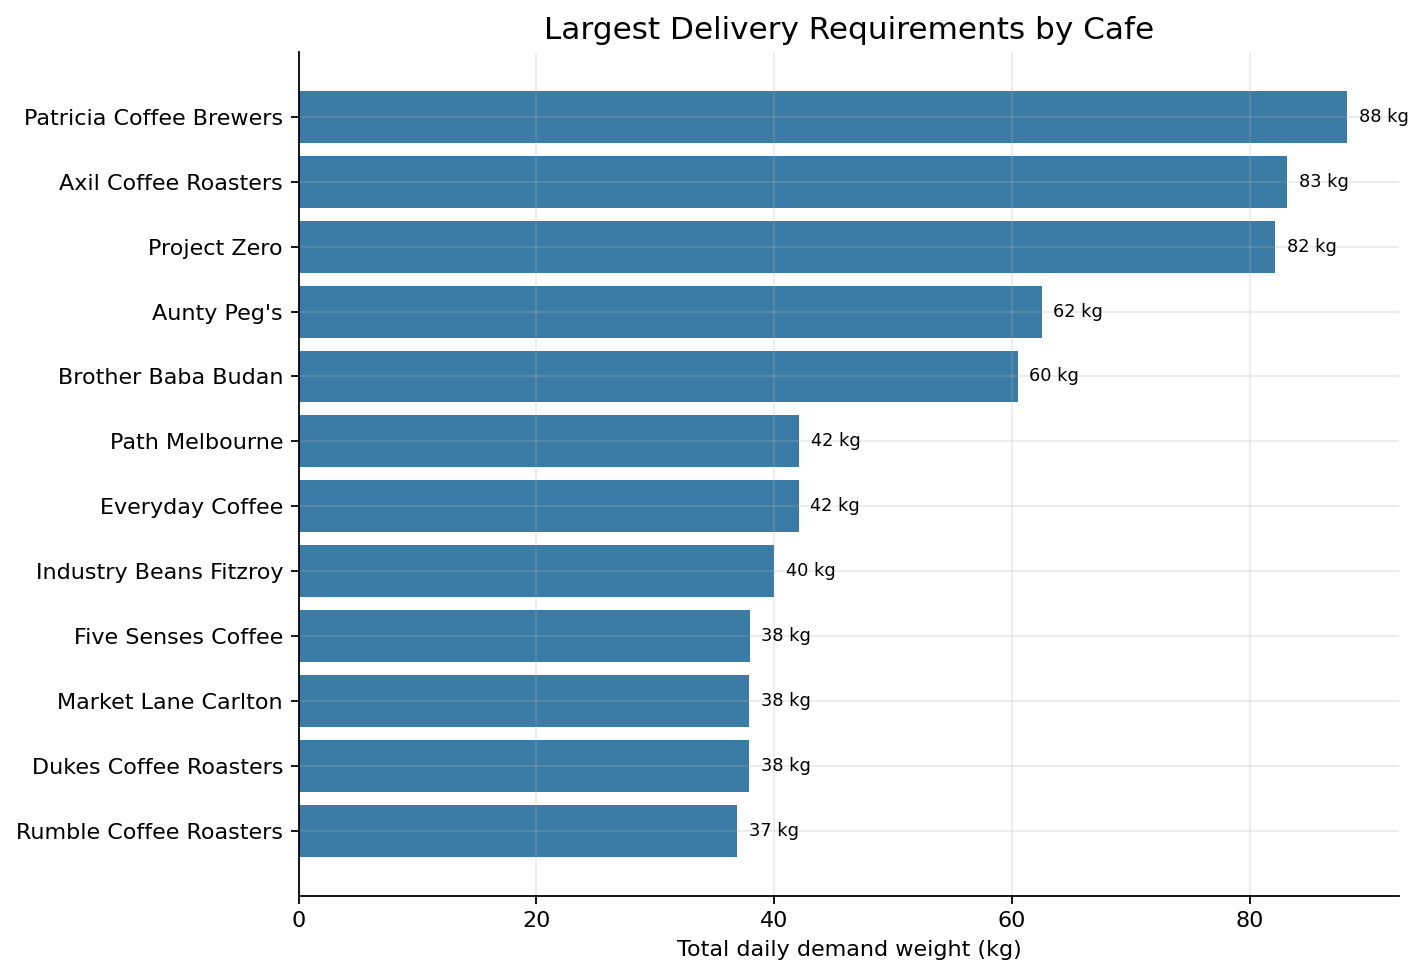

In [70]:
rank = cafe_data.sort_values('total_daily_weight_kg', ascending=False).head(12).sort_values('total_daily_weight_kg')

fig, ax = plt.subplots(figsize=(9, 6.2))
ax.barh(rank['cafe_name'], rank['total_daily_weight_kg'], color='#3A7CA5')
ax.set_title('Largest Delivery Requirements by Cafe')
ax.set_xlabel('Total daily demand weight (kg)')
ax.set_ylabel('')

for y, v in enumerate(rank['total_daily_weight_kg']):
    ax.text(v + 1, y, f'{v:.0f} kg', va='center', fontsize=8)

fig.tight_layout()
fig.savefig(OUT / '02_top_cafes_by_demand_weight.png', bbox_inches='tight')
plt.show()



This bar chart highlights the cafes with the largest daily delivery requirements. It shows which customers place the greatest pressure on van capacity and route planning.



## 3. Product Demand Mix



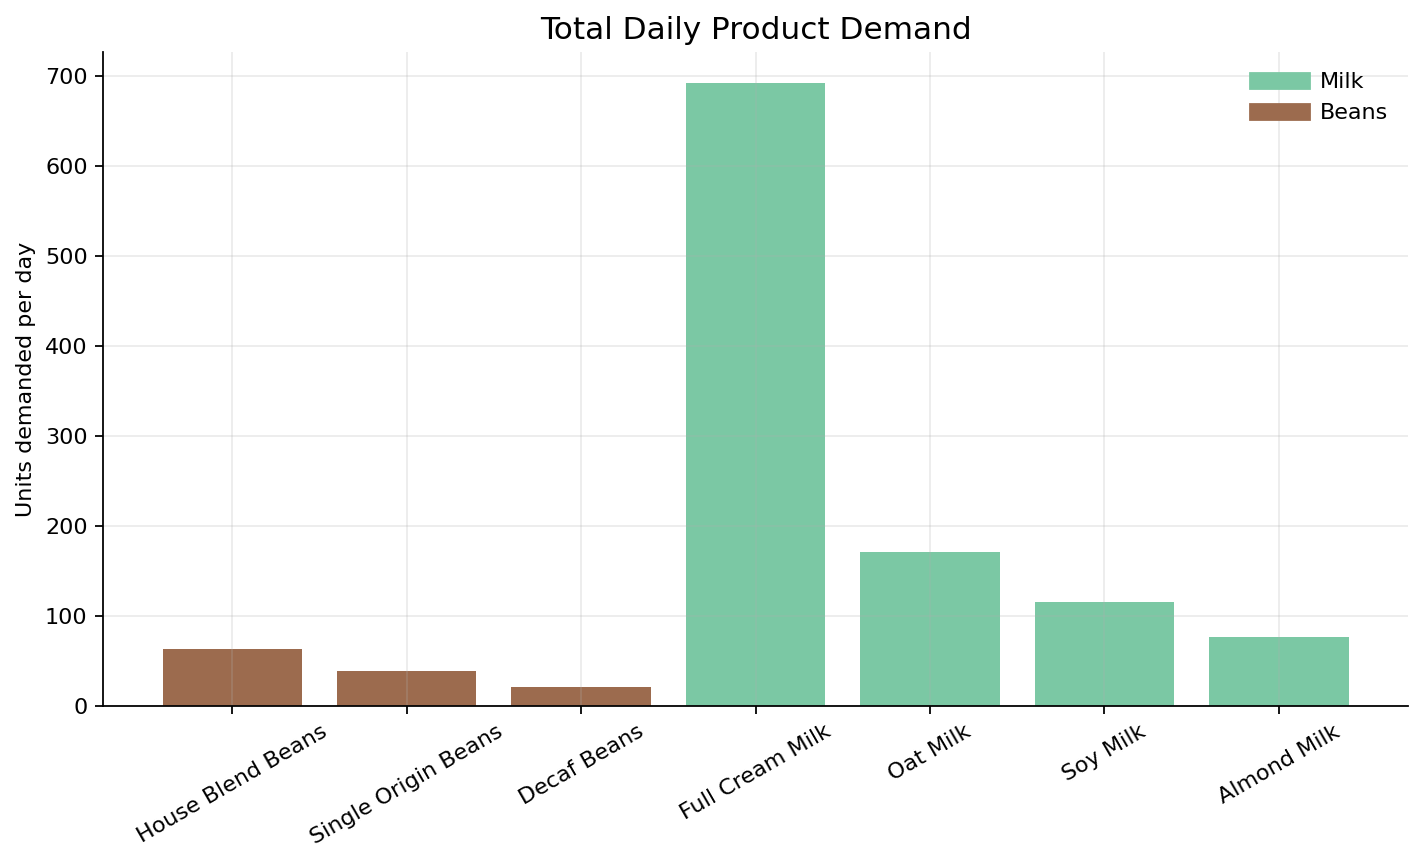

In [71]:
product_totals = (
    demands.groupby('product_id', as_index=False)['daily_demand'].sum()
    .merge(products, on='product_id')
    .sort_values(['category', 'daily_demand'], ascending=[True, False])
)

fig, ax = plt.subplots(figsize=(9, 5.5))
bar_colors = ['#7BC8A4' if c == 'milk' else '#9C6B4E' for c in product_totals['category']]
ax.bar(product_totals['product_name'], product_totals['daily_demand'], color=bar_colors)
ax.set_title('Total Daily Product Demand')
ax.set_ylabel('Units demanded per day')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)

legend_items = [
    Line2D([0], [0], color='#7BC8A4', lw=8, label='Milk'),
    Line2D([0], [0], color='#9C6B4E', lw=8, label='Beans'),
]
ax.legend(handles=legend_items, frameon=False)
fig.tight_layout()
fig.savefig(OUT / '03_product_demand_mix.png', bbox_inches='tight')
plt.show()



This chart summarises total daily demand by product. It separates milk and coffee bean products, which is important because milk is perishable and creates additional timing constraints.



## 4. OSRM Distance and Time Matrix Distribution



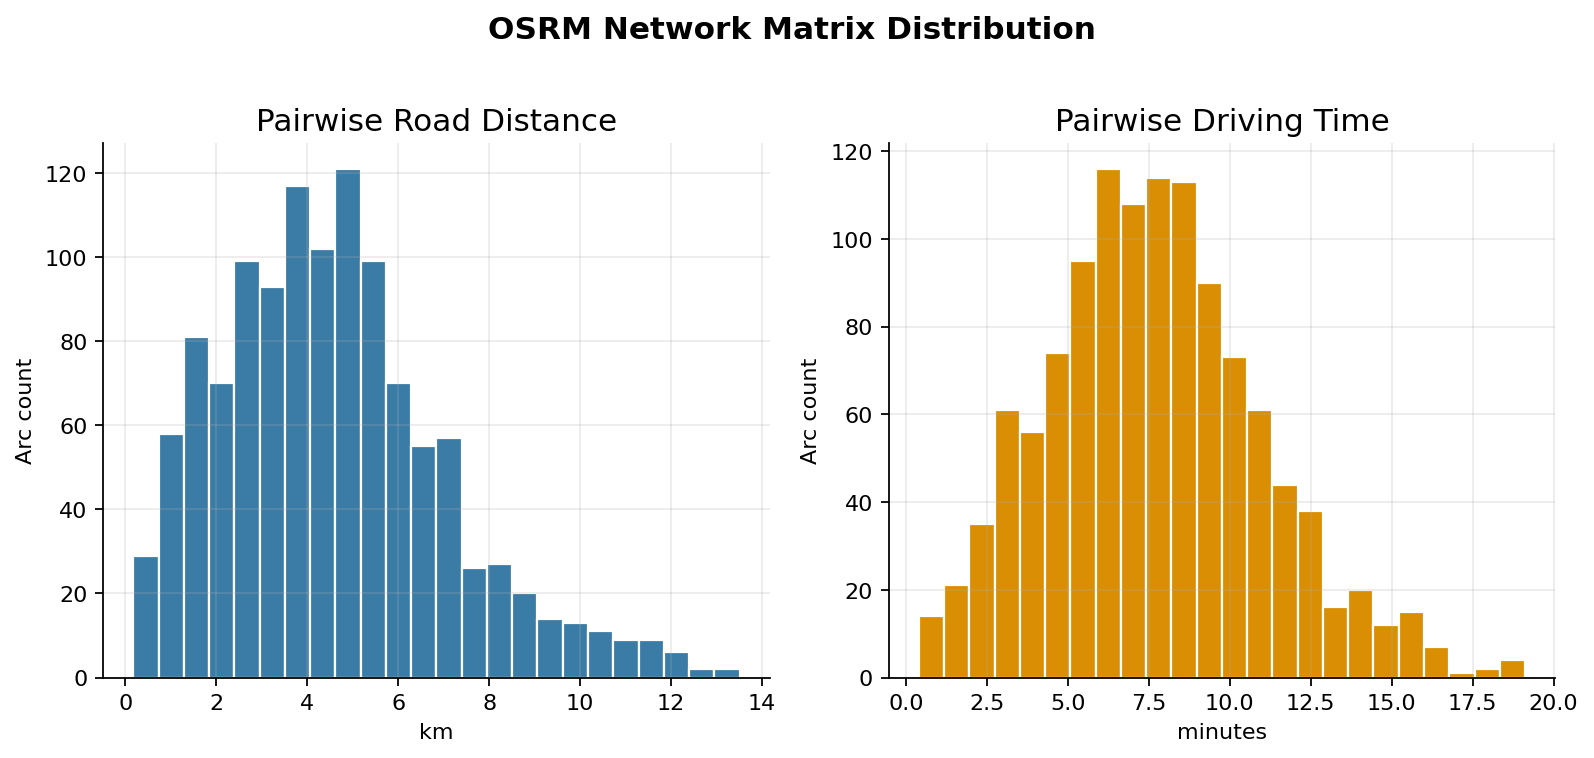

In [72]:
distance_values = distance_matrix.to_numpy().flatten()
time_values = time_matrix.to_numpy().flatten()
distance_values = distance_values[distance_values > 0]
time_values = time_values[time_values > 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
axes[0].hist(distance_values, bins=24, color='#3A7CA5', edgecolor='white')
axes[0].set_title('Pairwise Road Distance')
axes[0].set_xlabel('km')
axes[0].set_ylabel('Arc count')

axes[1].hist(time_values, bins=24, color='#D98E04', edgecolor='white')
axes[1].set_title('Pairwise Driving Time')
axes[1].set_xlabel('minutes')
axes[1].set_ylabel('Arc count')

fig.suptitle('OSRM Network Matrix Distribution', y=1.02, fontsize=14, weight='bold')
fig.tight_layout()
fig.savefig(OUT / '04_osrm_distance_time_distribution.png', bbox_inches='tight')
plt.show()



These histograms summarise the road distance and driving time values used in the optimisation model. The values come from the OSRM matrix rather than simple straight-line distance.



## 5. Gurobi Route Map

This parses the saved output from `gurobi.ipynb`. Routes are drawn as straight-line connections for visual clarity; the optimisation itself uses OSRM road distances and travel times.



In [73]:
def parse_routes_from_gurobi_notebook(notebook_path):
    nb = json.loads(Path(notebook_path).read_text())
    route_text = ''
    for cell in nb['cells']:
        for output in cell.get('outputs', []):
            route_text += ''.join(output.get('text', []))

    if 'Van routes:' not in route_text:
        raise ValueError('Could not find saved route output. Run gurobi.ipynb first and save it.')

    route_blocks = re.split(r'\n(?=van_\d+\n)', route_text.split('Van routes:')[-1].strip())
    routes = []

    for block in route_blocks:
        lines = [line.strip() for line in block.splitlines() if line.strip()]
        if not lines or not lines[0].startswith('van_'):
            continue

        van = lines[0]
        duration = None
        load = None
        capacity = None
        route_line = None

        for line in lines:
            if line.startswith('Route duration:'):
                duration = float(re.search(r'([0-9.]+)', line).group(1))
            elif ' -> ' in line:
                route_line = line
            elif line.startswith('Load:'):
                match = re.search(r'Load:\s*([0-9.]+) kg / ([0-9.]+) kg', line)
                if match:
                    load = float(match.group(1))
                    capacity = float(match.group(2))

        if route_line:
            routes.append({
                'van': van,
                'duration_hr': duration,
                'load_kg': load,
                'capacity_kg': capacity,
                'route': route_line.split(' -> '),
            })

    return routes

routes = parse_routes_from_gurobi_notebook(BASE / 'notebooks/gurobi.ipynb')
routes



[{'van': 'van_1',
  'duration_hr': 2.05,
  'load_kg': 411.07,
  'capacity_kg': 600.0,
  'route': ['Peter Hall Building UniMelb',
   'Jasper Coffee Fitzroy',
   'Everyday Coffee',
   "Aunty Peg's",
   'Proud Mary Coffee',
   'Lune Croissanterie Fitzroy',
   'Industry Beans Fitzroy',
   'Standing Room Fitzroy North',
   'Market Lane Coffee HQ',
   'Bench Coffee Co. Roastery',
   'Padre Coffee Brunswick East',
   'Core Roasters',
   'Code Black Coffee Brunswick',
   'Wide Open Road',
   'Disciple Roasters',
   'Peter Hall Building UniMelb']},
 {'van': 'van_2',
  'duration_hr': 1.14,
  'load_kg': 304.44,
  'capacity_kg': 600.0,
  'route': ['Peter Hall Building UniMelb',
   'Seven Seeds Coffee Roasters',
   'Small Batch Roasting Co.',
   'Path Melbourne',
   'Patricia Coffee Brewers',
   'Brother Baba Budan',
   'Little Rogue',
   'Traveller Coffee',
   'Peter Hall Building UniMelb']},
 {'van': 'van_5',
  'duration_hr': 2.34,
  'load_kg': 492.22,
  'capacity_kg': 500.0,
  'route': ['Peter H

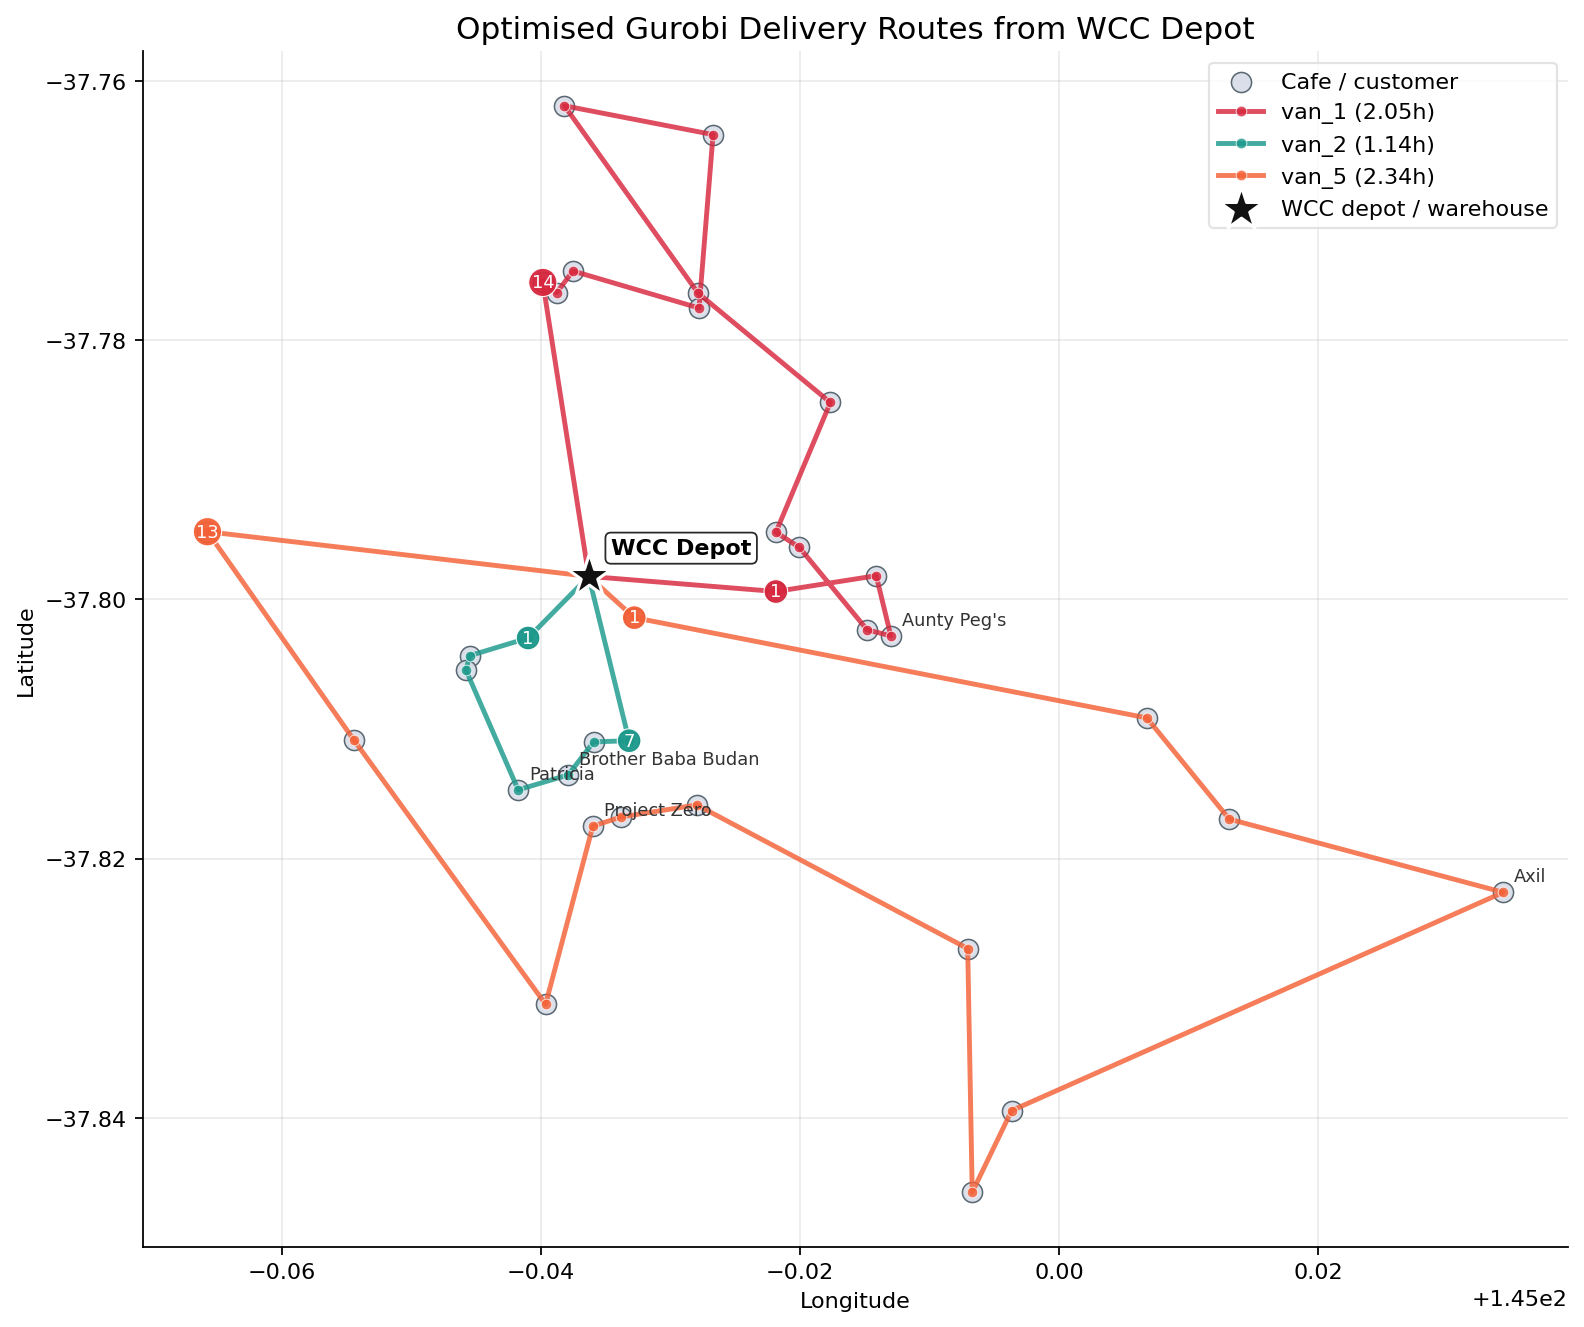

In [ ]:
coords = {row['name']: (row['longitude'], row['latitude']) for _, row in locations.iterrows()}
route_colors = ['#D7263D', '#1B998B', '#F46036', '#2E86AB', '#7B2CBF']

fig, ax = plt.subplots(figsize=(10, 8.5))

ax.scatter(
    cafe_data['longitude'],
    cafe_data['latitude'],
    s=82,
    c='#D8DEE9',
    edgecolor='#52616B',
    linewidth=0.7,
    alpha=0.95,
    label='Cafe / customer',
    zorder=2,
)

for idx, route in enumerate(routes):
    pts = [coords[name] for name in route['route'] if name in coords]
    xs, ys = zip(*pts)
    color = route_colors[idx % len(route_colors)]
    ax.plot(
        xs,
        ys,
        '-o',
        lw=2.2,
        ms=4.8,
        alpha=0.82,
        color=color,
        markeredgecolor='white',
        markeredgewidth=0.4,
        label=f"{route['van']} ({route['duration_hr']:.2f}h)",
        zorder=3,
    )

    for stop_no, name in enumerate(route['route'][1:-1], start=1):
        if stop_no in (1, len(route['route']) - 2):
            x, y = coords[name]
            ax.text(
                x,
                y,
                str(stop_no),
                fontsize=8,
                color='white',
                ha='center',
                va='center',
                bbox=dict(boxstyle='circle,pad=0.16', facecolor=color, edgecolor='white', linewidth=0.5, alpha=0.95),
                zorder=5,
            )

ax.scatter(
    depot['longitude'],
    depot['latitude'],
    s=420,
    marker='*',
    c='#111111',
    edgecolor='white',
    linewidth=1.4,
    label='WCC depot / warehouse',
    zorder=6,
)
ax.annotate(
    'WCC Depot',
    (depot['longitude'], depot['latitude']),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    weight='bold',
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#111111', linewidth=0.8, alpha=0.9),
    zorder=7,
)

# Label a few high-demand cafes only
for _, row in cafe_data.nlargest(5, 'total_daily_weight_kg').iterrows():
    short_name = row['cafe_name'].replace(' Coffee', '').replace(' Roasters', '').replace(' Brewers', '')
    ax.annotate(
        short_name,
        (row['longitude'], row['latitude']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        color='#333333',
        zorder=7,
    )

ax.set_title('Optimised Gurobi Delivery Routes from WCC Depot')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(frameon=True, facecolor='white', edgecolor='#DDDDDD', loc='best')
ax.set_aspect('equal', adjustable='box')
fig.tight_layout()
fig.savefig(OUT / '05_gurobi_route_map.png', bbox_inches='tight')
plt.show()




This map visualises the delivery routes selected by the Gurobi model. The coloured lines show different vans; routes are drawn as straight-line connections for readability, while the model uses OSRM road distance and travel time data.



## 6. Van Utilisation and Route Duration



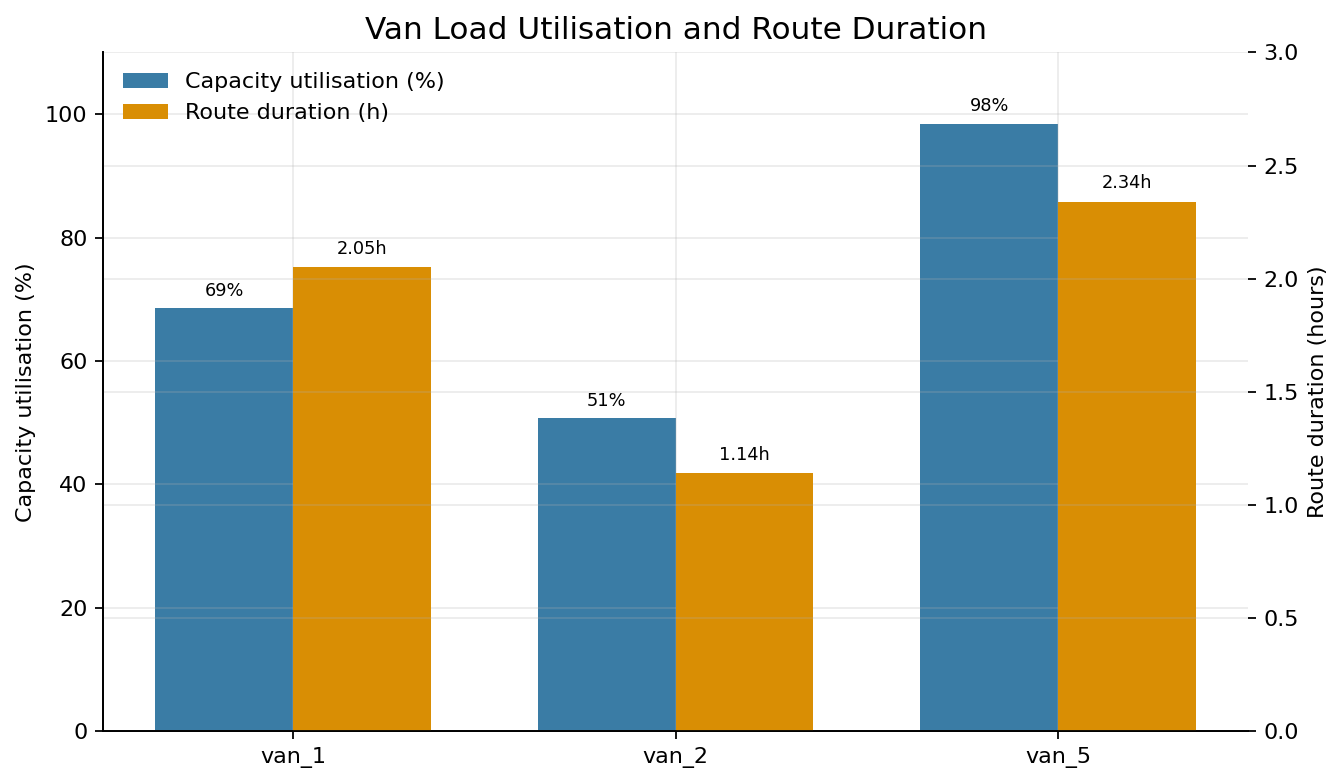

In [75]:
route_df = pd.DataFrame(routes)
route_df['utilisation_pct'] = route_df['load_kg'] / route_df['capacity_kg'] * 100

fig, ax1 = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(route_df))

ax1.bar(x - 0.18, route_df['utilisation_pct'], width=0.36, color='#3A7CA5', label='Capacity utilisation (%)')
ax1.set_ylabel('Capacity utilisation (%)')
ax1.set_ylim(0, 110)

ax2 = ax1.twinx()
ax2.bar(x + 0.18, route_df['duration_hr'], width=0.36, color='#D98E04', label='Route duration (h)')
ax2.set_ylabel('Route duration (hours)')
ax2.set_ylim(0, max(3, route_df['duration_hr'].max() + 0.4))

ax1.set_xticks(x)
ax1.set_xticklabels(route_df['van'])
ax1.set_title('Van Load Utilisation and Route Duration')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc='upper left')

for i, row in route_df.iterrows():
    ax1.text(i - 0.18, row['utilisation_pct'] + 2, f"{row['utilisation_pct']:.0f}%", ha='center', fontsize=8)
    ax2.text(i + 0.18, row['duration_hr'] + 0.06, f"{row['duration_hr']:.2f}h", ha='center', fontsize=8)

fig.tight_layout()
fig.savefig(OUT / '06_van_utilisation_route_duration.png', bbox_inches='tight')
plt.show()



This chart compares each used van's load utilisation and route duration. It shows whether the solution uses vehicle capacity efficiently while keeping routes feasible for perishable milk delivery.



## 7. Profit Objective Breakdown

These values are from the saved output of `gurobi model 2.ipynb`. Update them if the model settings change.



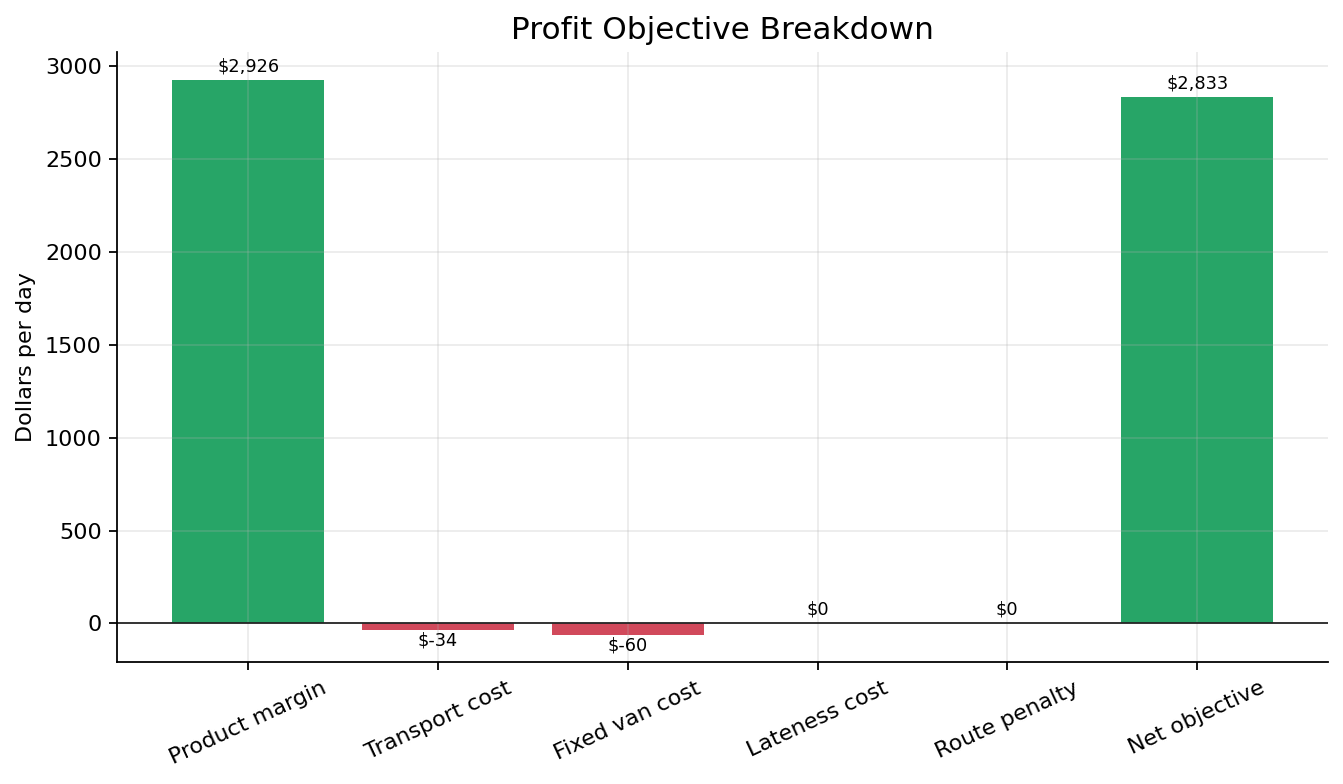

In [76]:
breakdown = pd.DataFrame({
    'component': ['Product margin', 'Transport cost', 'Fixed van cost', 'Lateness cost', 'Route penalty', 'Net objective'],
    'value': [2926.5, -33.8109, -60.0, 0.0, 0.0, 2832.68905],
})

fig, ax = plt.subplots(figsize=(8.5, 5))
bar_colors = ['#27A567' if value >= 0 else '#D1495B' for value in breakdown['value']]
ax.bar(breakdown['component'], breakdown['value'], color=bar_colors)
ax.axhline(0, color='#222222', lw=0.8)
ax.set_title('Profit Objective Breakdown')
ax.set_ylabel('Dollars per day')
ax.tick_params(axis='x', rotation=25)

for i, value in enumerate(breakdown['value']):
    va = 'bottom' if value >= 0 else 'top'
    ax.text(i, value + (25 if value >= 0 else -8), f'${value:,.0f}', ha='center', va=va, fontsize=8)

fig.tight_layout()
fig.savefig(OUT / '07_profit_objective_breakdown.png', bbox_inches='tight')
plt.show()



This chart breaks down the profit objective into revenue margin and cost components. It shows that the model is maximising net profit, not simply minimising travel distance.



## Generated Files



In [77]:
for path in sorted(OUT.glob('*.png')):
    print(path)



../plots/01_cafe_network_demand_bubble.png
../plots/02_top_cafes_by_demand_weight.png
../plots/03_product_demand_mix.png
../plots/04_osrm_distance_time_distribution.png
../plots/05_gurobi_route_map.png
../plots/06_van_utilisation_route_duration.png
../plots/07_profit_objective_breakdown.png
../plots/distance_heatmap.png
../plots/time_heatmap.png
